# Decision: does any contractive configuration earn its place?

This notebook combines the prediction results of `part_1`, the latent geometry results of
`part_2` and the training cost measured in `part_0_2` into one decision about which, if
any, contractive penalty configuration should be carried forward. It answers whether a
configuration improves prediction, what it does to the representation, and whether the
improvement justifies its compute cost.

It performs no model inference of its own. Every quantity is read from the persisted
result tables of the three upstream notebooks, so the decision is reproducible from stored
records and cannot silently diverge from the analyses it summarizes.

## Introduction

Three axes bear on the decision, and a configuration that wins on one while losing on
another is not a candidate:

1. **Prediction.** Does the head rank molecules better than the unregularized baseline, on
   held-out pixels, paired by repetition?
2. **Representation.** Does the latent keep its variation and its dimensional usage, and
   does the penalty actually reduce the encoder's sensitivity, which is what it exists to
   do?
3. **Cost.** How much wall time does the configuration add per epoch?

### Assumptions

- **Nominal weights are not comparable across input geometries.** The weight $\lambda$
  multiplies a penalty measured in the geometry it was configured with, and the Euclidean
  and Fisher-Rao penalties are on different scales. Comparing the two arms at equal
  $\lambda$ compares nothing. Where the two arms are placed on a common axis, that axis is
  a measured quantity, realized encoder sensitivity, not the configured weight.
- **The two hinge variants are different functions, not different settings.** The legacy
  Euclidean hinge penalizes $[\lVert J\rVert_F^2-\tau^2]_+$ while the Fisher-Rao variant
  penalizes $s^2+\alpha[s-\tau]_+^2$ on the spectral norm. They are shown as separate
  families and a trend must not be read across them.
- **Fifteen swept cells are compared against one baseline without a multiple-comparison
  correction.** A single cell whose interval barely excludes zero is weak evidence; the
  pattern within a penalty family is what supports a decision.
- **Decision thresholds are stated before the tables are read.** They are fixed in the
  configuration cell below rather than chosen after seeing which cells would pass.

### Notation

A grid cell is $c = (\text{geometry}, \text{penalty metric}, \lambda)$ with repetitions
$r=0,\dots,4$. For metric $m$, $\delta_m(c) = \frac{1}{R}\sum_r [m(c,r) - m(\text{baseline},r)]$
is the paired mean difference against the baseline and $[\ell_m(c), h_m(c)]$ its 95%
interval. A cell *separates* on $m$ when that interval excludes zero.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points
from msi_autoencoder_wrapper.utils.logger import get_custom_logger

logger = get_custom_logger("decision_summary")

## Configuration and stored inputs

In [2]:
NOTEBOOK_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned")
PREDICTION_RESULTS = NOTEBOOK_DIR / "part_1_prediction_metric_weight_sweep_results"
GEOMETRY_RESULTS = NOTEBOOK_DIR / "part_2_latent_geometry_metric_weight_sweep_results"
DYNAMICS_RESULTS = NOTEBOOK_DIR / "part_0_2_campaign_training_dynamics_results"
ARTIFACT_DIR = NOTEBOOK_DIR / "part_3_decision_summary_results"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Decision criteria, fixed before any table below is read.
PRIMARY_METRIC = "average_precision"
BASELINE_CELL = "baseline (no contractive)"
MAX_TRACE_LOSS_FRACTION = 0.20      # a cell may not lose more than this share of latent variation
MAX_COST_MULTIPLE = 2.5             # a cell may not cost more than this multiple of baseline epoch time

theme = resolve_theme(None)
theme.apply()

prediction_frame = pd.read_csv(PREDICTION_RESULTS / "prediction_metrics.csv")
prediction_contrasts = pd.read_csv(PREDICTION_RESULTS / "baseline_contrasts.csv")
metric_correlations = pd.read_csv(PREDICTION_RESULTS / "metric_correlations.csv")
geometry_frame = pd.read_csv(GEOMETRY_RESULTS / "latent_geometry.csv")
geometry_contrasts = pd.read_csv(GEOMETRY_RESULTS / "baseline_contrasts.csv")
sensitivity_frame = pd.read_csv(GEOMETRY_RESULTS / "angular_sensitivity.csv")
stability_frame = pd.read_csv(GEOMETRY_RESULTS / "representation_stability.csv")
duration_summary = pd.read_csv(DYNAMICS_RESULTS / "duration_summary.csv")
health_frame = pd.read_csv(DYNAMICS_RESULTS / "training_health.csv")
prediction_metadata = json.loads((PREDICTION_RESULTS / "metadata.json").read_text())

FAIR_SCOPE = "train-active and test-active"
CELL_ORDER = (
    prediction_frame.drop_duplicates("cell_label")
    .sort_values(["input_geometry", "penalty_metric", "weight"], na_position="first")
    ["cell_label"].tolist()
)
FAMILY_OF = prediction_frame.drop_duplicates("cell_label").set_index("cell_label")[["input_geometry", "penalty_metric"]]
FAMILIES = sorted({tuple(FAMILY_OF.loc[cell]) for cell in CELL_ORDER})
FAMILY_COLOR = {family: theme.color_for_model("/".join(family), index) for index, family in enumerate(FAMILIES)}
CELL_COLOR = {cell: FAMILY_COLOR[tuple(FAMILY_OF.loc[cell])] for cell in CELL_ORDER}
print(f"{len(CELL_ORDER)} cell(s); all {int(health_frame['healthy'].sum())}/{len(health_frame)} run(s) healthy")

28 cell(s); all 140/140 run(s) healthy


## The three decision quantities as distributions

### Methodology

#### Theoretical

A decision taken on three point estimates cannot distinguish a consistent effect from one
divergent seed, and those have opposite consequences. Each decision quantity is therefore
shown as its distribution over repetitions before any threshold is applied:

- ranking quality, as average precision on held-out pixels in the fair class scope;
- retained latent variation, as $\operatorname{tr}\Sigma$;
- realized encoder sensitivity, as the mean angular displacement at the largest
  perturbation, which is the quantity the penalty is meant to reduce.

#### Implementation

All three are read from the upstream long-form tables and grouped by grid cell without
recomputation. The baseline appears as its own cell in every panel so the comparison is
visual rather than arithmetic.

#### Figure descriptions

Three stacked panels sharing one x-axis of grid cells, ordered by input geometry, then
penalty metric, then weight. The y-axis of the first panel is average precision on the
evaluation split within the fair scope, of the second the latent covariance trace, and of
the third the mean angular displacement in degrees at the largest perturbation. Each violin
is the distribution over that cell's five repetitions with every repetition drawn as a
point; color encodes penalty family and the dashed line is the baseline's mean. Higher is
better in the first panel, higher means more retained variation in the second, and lower
means a less sensitive encoder in the third.

### Remarks

### Notes

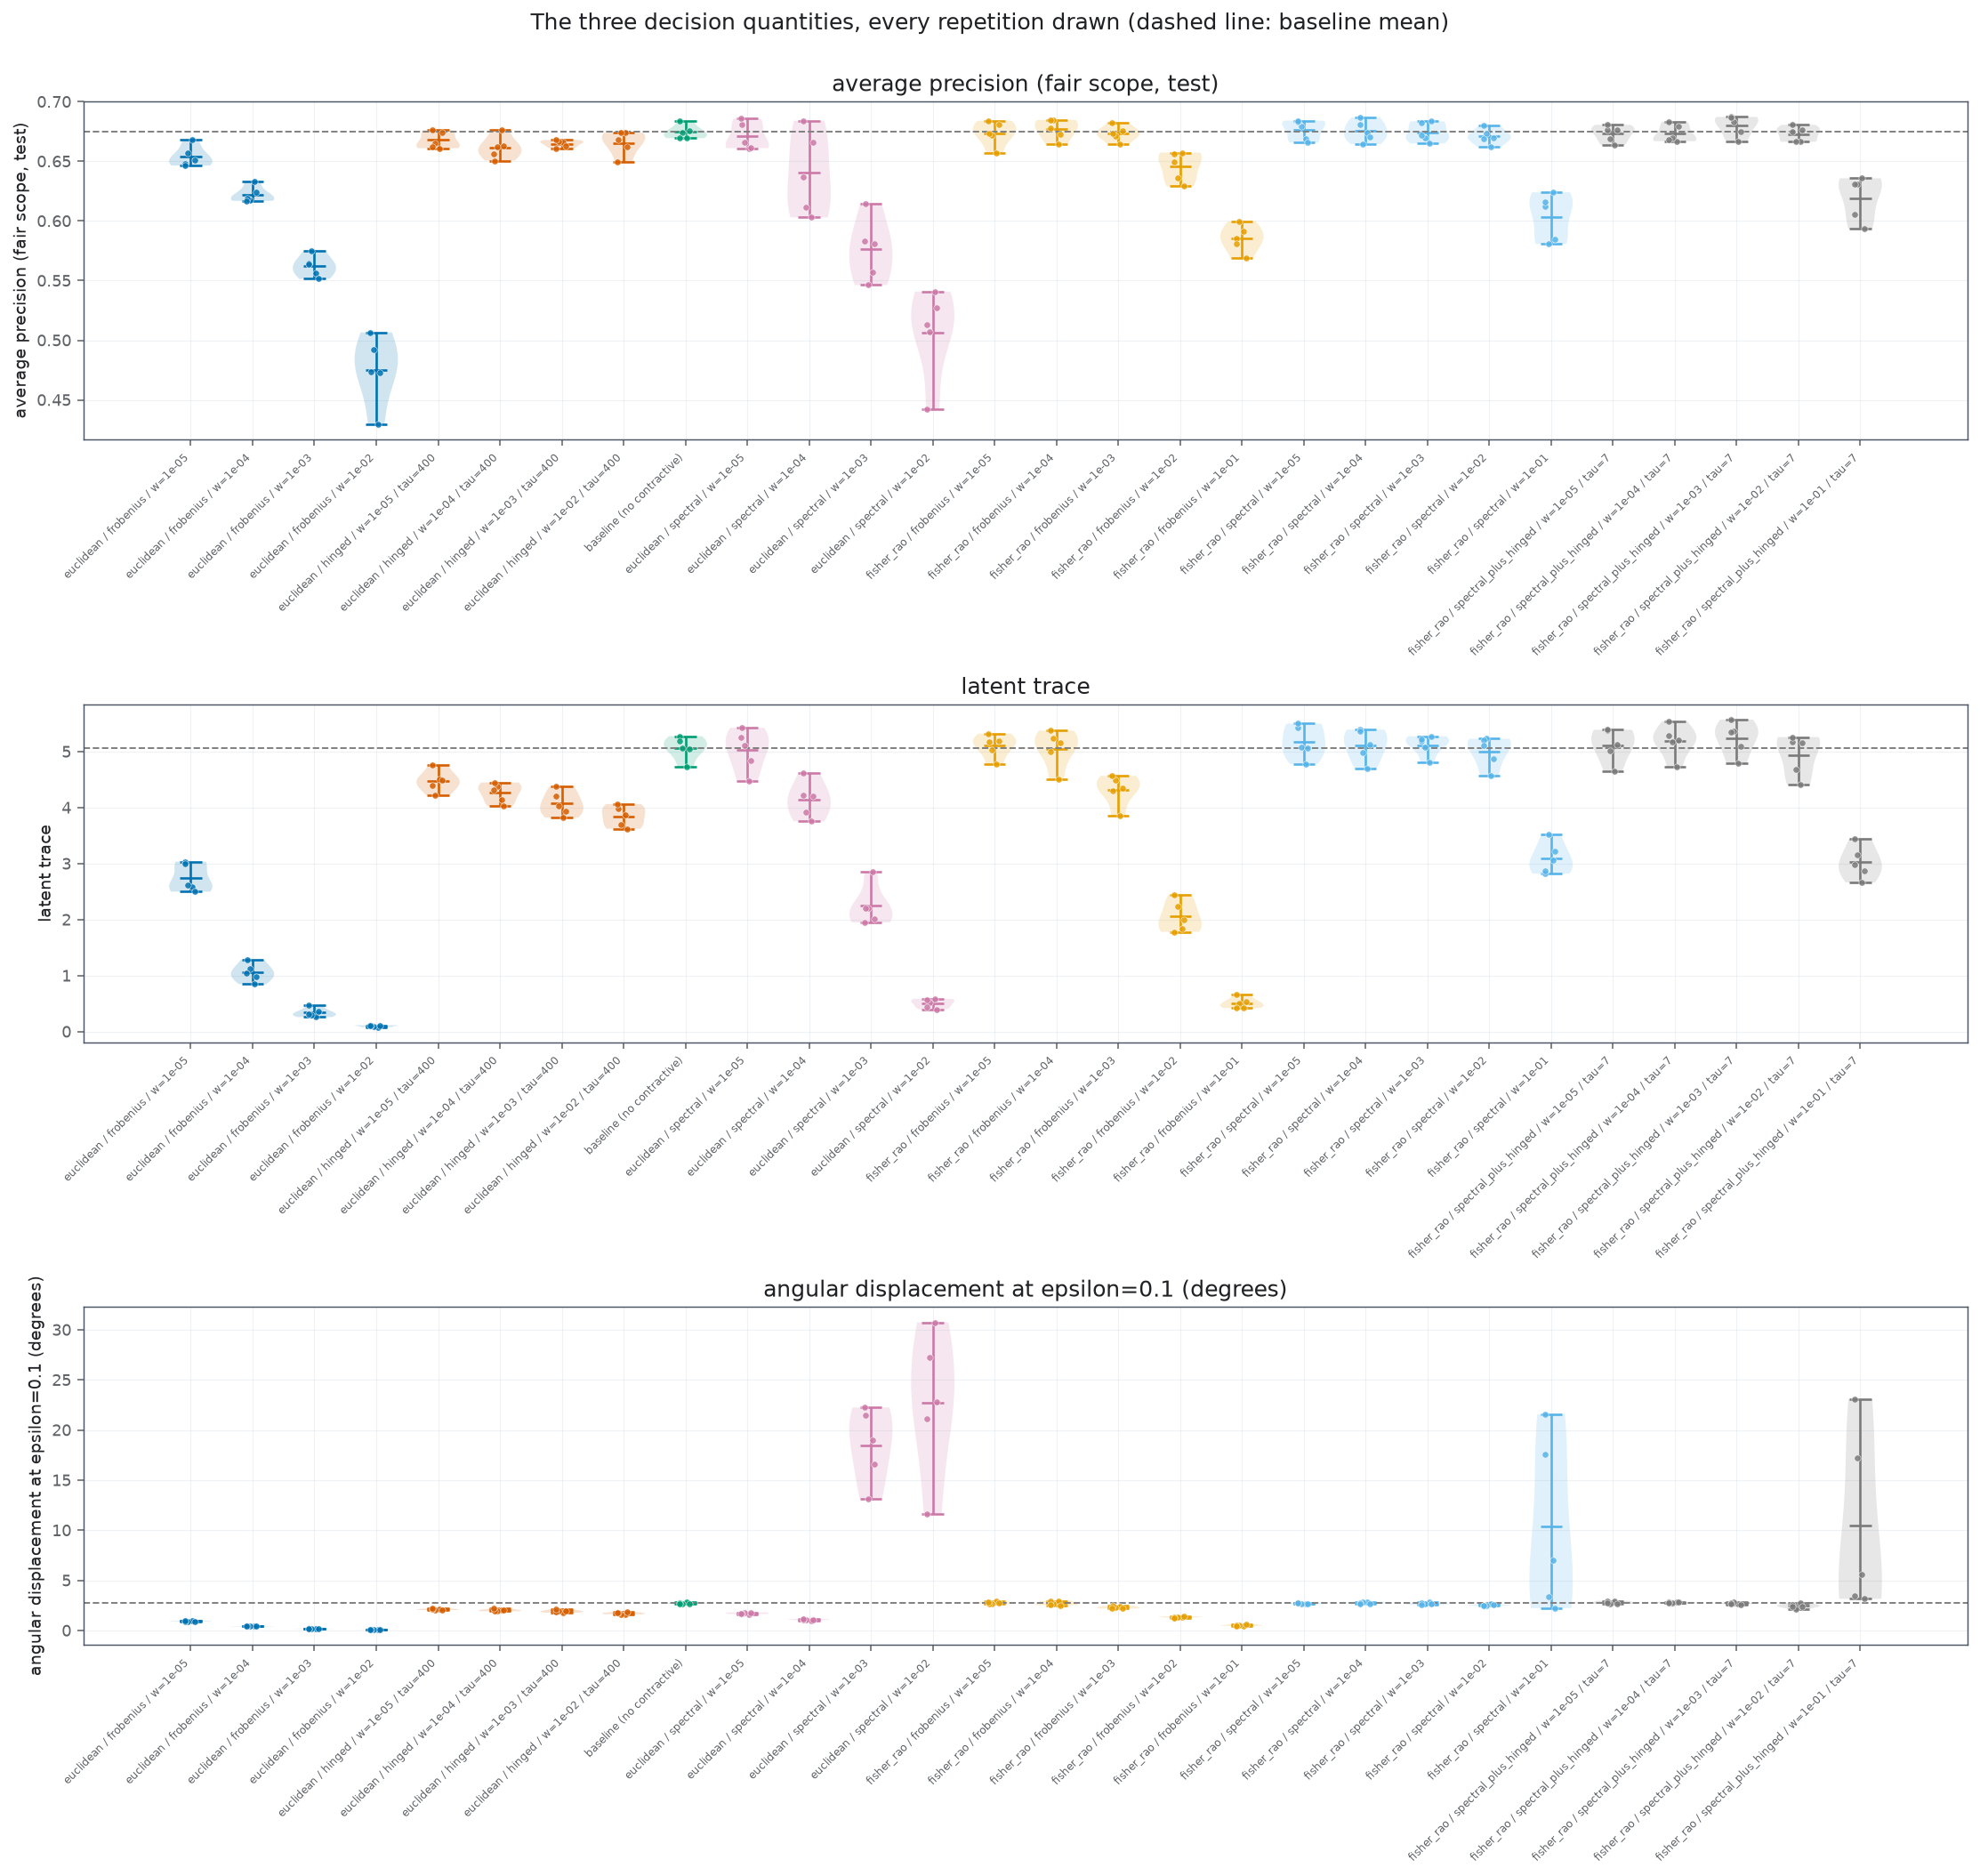

In [3]:
largest_epsilon = sensitivity_frame["epsilon"].max()
panels = [
    (
        "average precision (fair scope, test)",
        prediction_frame.query("metric == @PRIMARY_METRIC and scope == @FAIR_SCOPE and split == 'test'"),
        "value",
    ),
    (
        "latent trace",
        geometry_frame.query("metric == 'trace'"),
        "value",
    ),
    (
        f"angular displacement at epsilon={largest_epsilon:g} (degrees)",
        sensitivity_frame.query("epsilon == @largest_epsilon"),
        "mean_angle_degrees",
    ),
]

figure, axes = plt.subplots(len(panels), 1, figsize=(16.0, 5.0 * len(panels)), dpi=theme.figure_dpi)
for axis, (title, frame, column) in zip(axes, panels):
    samples = {cell: group[column].dropna().to_numpy() for cell, group in frame.groupby("cell_label")}
    for position, cell in enumerate(CELL_ORDER):
        values = samples.get(cell)
        if values is None or not len(values):
            continue
        plot_violin_with_points(
            values, position=position, ax=axis, width=0.7,
            color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
        )
    if BASELINE_CELL in samples and len(samples[BASELINE_CELL]):
        axis.axhline(float(np.mean(samples[BASELINE_CELL])), color="grey", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(CELL_ORDER)))
    axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
    axis.set(ylabel=title, title=title)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("The three decision quantities, every repetition drawn (dashed line: baseline mean)", y=1.001, fontsize=13)
figure.tight_layout()

## Prediction against geometry

### Methodology

#### Theoretical

If a penalty helps prediction, the mechanism must be visible in the representation, since
the penalty touches nothing else. Relating each prediction metric to each geometry
statistic across cells tests whether such a mechanism exists and identifies which
representational property carries it.

Four geometry statistics are used, chosen because they measure different things: trace
measures how much variation survives, participation ratio how it is spread over
directions, angular displacement how sensitive the encoder is, and cross-seed neighborhood
overlap how reproducible the representation is. Cloud asymmetry is included for continuity
with earlier analyses, with the caveat that the bottleneck `LayerNorm` partly fixes it by
construction, so it is the least informative of the five.

Prediction is represented by both metric families, since `part_1` establishes that
threshold metrics can move for reasons that have nothing to do with representation
quality. A geometry statistic that tracks the threshold metrics but not average precision
is describing a calibration effect, not an information effect.

#### Implementation

Cell means over repetitions are joined across the two upstream tables on the cell label.
Each panel is one (prediction metric, geometry statistic) pair, with one point per cell.

#### Figure descriptions

A grid of scatter panels. Within each panel the x-axis is the named geometry statistic and
the y-axis the named prediction metric, both as means over the cell's repetitions; each
point is one grid cell and color encodes penalty family. The baseline is drawn as a black
cross. A panel whose points fall on a monotone trend indicates that prediction quality
moves with that representational property across the grid; a shapeless cloud indicates it
does not.

### Remarks

### Notes

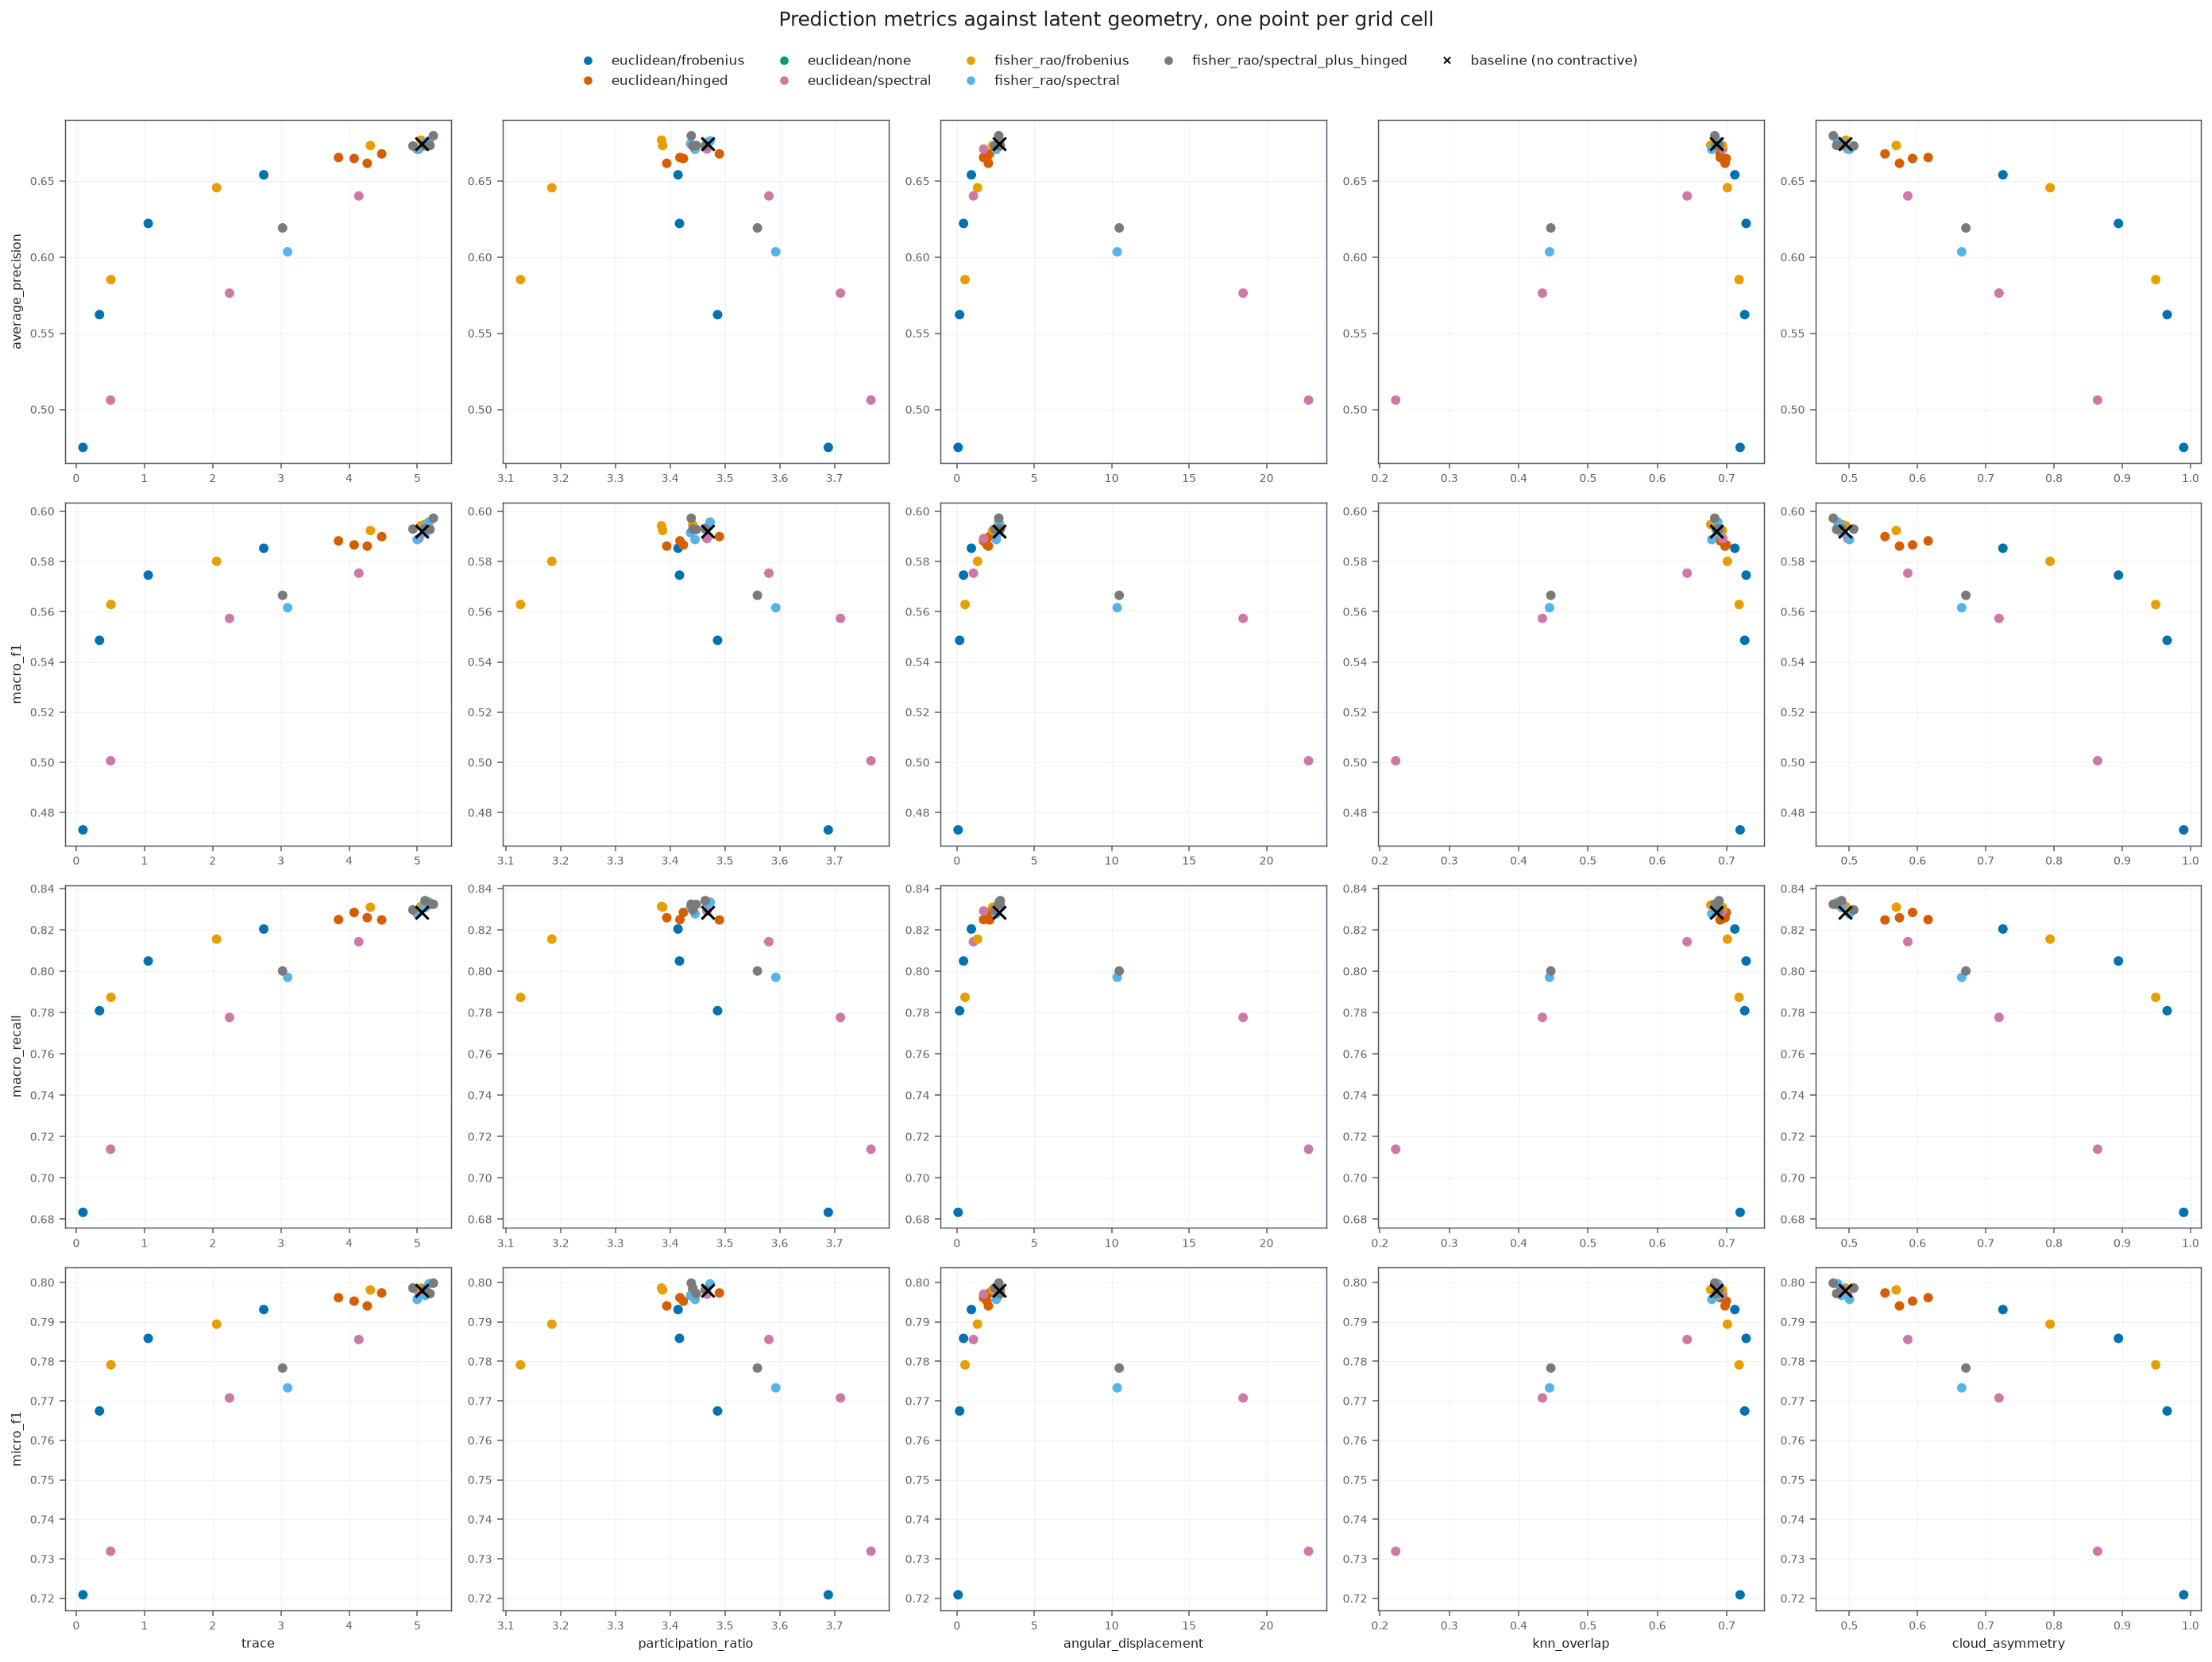

In [4]:
prediction_means = (
    prediction_frame.query("scope == @FAIR_SCOPE and split == 'test'")
    .pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
)
geometry_means = geometry_frame.pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
sensitivity_means = (
    sensitivity_frame.query("epsilon == @largest_epsilon")
    .groupby("cell_label")["mean_angle_degrees"].mean().rename("angular_displacement")
)
stability_means = (
    stability_frame.query("metric == 'knn_overlap'")
    .groupby("cell_label")["value"].mean().rename("knn_overlap")
)
joined = prediction_means.join([geometry_means, sensitivity_means, stability_means], how="inner")

PREDICTION_AXES = ["average_precision", "macro_f1", "macro_recall", "micro_f1"]
GEOMETRY_AXES = ["trace", "participation_ratio", "angular_displacement", "knn_overlap", "cloud_asymmetry"]

figure, axes = plt.subplots(len(PREDICTION_AXES), len(GEOMETRY_AXES), figsize=(4.0 * len(GEOMETRY_AXES), 3.6 * len(PREDICTION_AXES)), dpi=theme.figure_dpi)
for row, prediction_metric in enumerate(PREDICTION_AXES):
    for column, geometry_metric in enumerate(GEOMETRY_AXES):
        axis = axes[row, column]
        values = joined[[geometry_metric, prediction_metric]].dropna()
        swept = values.drop(index=BASELINE_CELL, errors="ignore")
        axis.scatter(
            swept[geometry_metric], swept[prediction_metric],
            color=[CELL_COLOR[cell] for cell in swept.index], s=38, edgecolor="none",
        )
        if BASELINE_CELL in values.index:
            axis.scatter(
                values.loc[BASELINE_CELL, geometry_metric], values.loc[BASELINE_CELL, prediction_metric],
                marker="x", color="black", s=70, linewidth=1.6,
            )
        axis.set_xlabel(geometry_metric if row == len(PREDICTION_AXES) - 1 else "", fontsize=8)
        axis.set_ylabel(prediction_metric if column == 0 else "", fontsize=8)
        axis.tick_params(labelsize=7)
        axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=FAMILY_COLOR[f], label="/".join(f)) for f in FAMILIES]
handles.append(plt.Line2D([], [], marker="x", linestyle="", color="black", label=BASELINE_CELL))
figure.legend(handles=handles, loc="upper center", ncol=min(len(handles), 5), frameon=theme.legend_frame, bbox_to_anchor=(0.5, 1.015))
figure.suptitle("Prediction metrics against latent geometry, one point per grid cell", y=1.035, fontsize=13)
figure.tight_layout()

## The two arms on a common axis

### Methodology

#### Theoretical

The Euclidean and Fisher-Rao arms cannot be compared at equal $\lambda$, because $\lambda$
scales penalties measured in different geometries. They can be compared at equal *realized*
contraction: how much the encoder's sensitivity actually fell. Placing both arms on that
axis answers the question the nominal weight cannot, namely whether one geometry buys more
prediction quality for the same amount of contraction.

Reading the figure requires care in one respect. Each arm's own weight sweep traces a path
along this axis, so a point's position reflects both its geometry and its weight. The
comparison of interest is vertical: at a given realized sensitivity, which arm sits higher.

#### Implementation

Cell means of realized angular displacement at the largest perturbation are plotted
against cell means of average precision, with the two arms distinguished by marker and the
weight within each arm by marker size.

#### Figure descriptions

The x-axis is mean angular displacement in degrees at the largest perturbation, decreasing
to the right so that stronger contraction lies right; the y-axis is average precision on
the evaluation split within the fair scope. Each point is one grid cell, color encodes
penalty family, marker size encodes the nominal weight with larger meaning stronger, and
the black cross is the baseline. Points connected by a line belong to the same family and
trace that family's weight sweep. A family whose curve lies above another at the same
x-position delivers more prediction quality for the same realized contraction.

### Remarks

### Notes

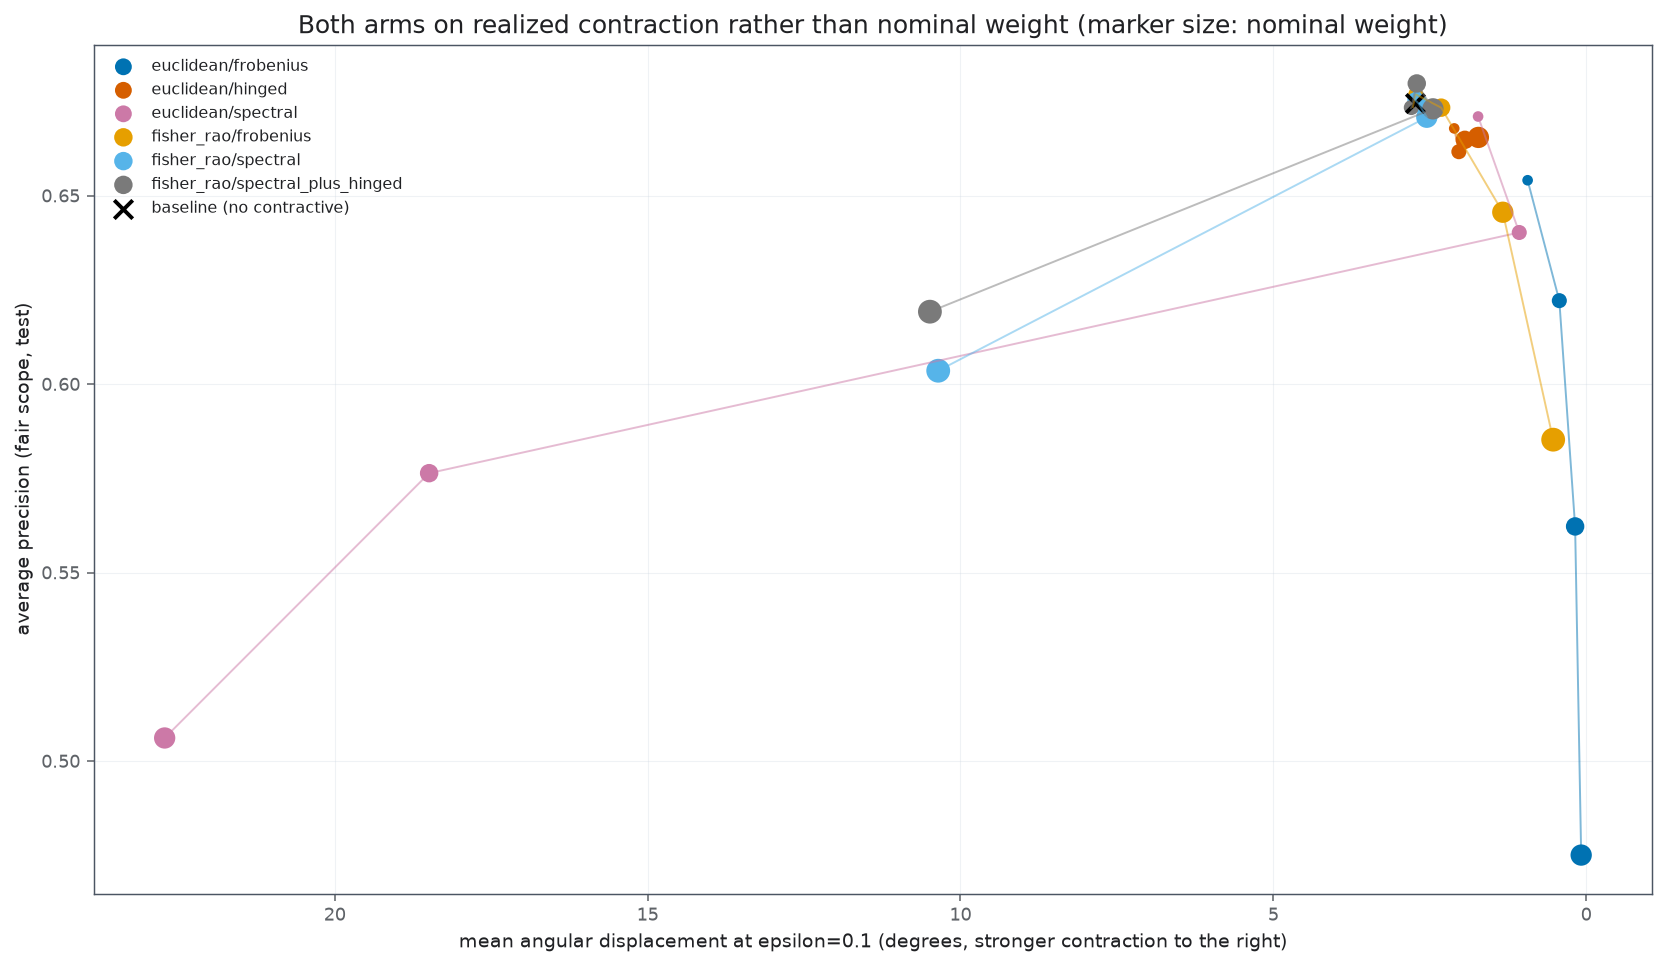

In [5]:
common = joined[["angular_displacement", "average_precision"]].dropna()
weights = (
    prediction_frame.drop_duplicates("cell_label").set_index("cell_label")["weight"]
)
figure, ax = plt.subplots(figsize=(12.0, 7.0), dpi=theme.figure_dpi)
for family in FAMILIES:
    cells = [cell for cell in CELL_ORDER if tuple(FAMILY_OF.loc[cell]) == family and cell in common.index and cell != BASELINE_CELL]
    if not cells:
        continue
    ordered = common.loc[cells].assign(weight=weights.loc[cells]).sort_values("weight")
    sizes = 30 + 120 * (np.log10(ordered["weight"]) - np.log10(weights.min())) / max(np.log10(weights.max()) - np.log10(weights.min()), 1e-9)
    ax.plot(ordered["angular_displacement"], ordered["average_precision"], color=FAMILY_COLOR[family], alpha=0.5, linewidth=1)
    ax.scatter(
        ordered["angular_displacement"], ordered["average_precision"],
        s=sizes, color=FAMILY_COLOR[family], edgecolor="none", label="/".join(family),
    )
if BASELINE_CELL in common.index:
    ax.scatter(
        common.loc[BASELINE_CELL, "angular_displacement"], common.loc[BASELINE_CELL, "average_precision"],
        marker="x", color="black", s=90, linewidth=2, label=BASELINE_CELL,
    )
ax.invert_xaxis()
ax.set(
    xlabel=f"mean angular displacement at epsilon={largest_epsilon:g} (degrees, stronger contraction to the right)",
    ylabel="average precision (fair scope, test)",
    title="Both arms on realized contraction rather than nominal weight (marker size: nominal weight)",
)
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Decision table

### Methodology

#### Theoretical

A configuration is carried forward only if it satisfies all three criteria stated in the
configuration cell:

1. its paired interval on average precision against the baseline lies strictly above zero;
2. it retains at least $1-\text{MAX\_TRACE\_LOSS\_FRACTION}$ of the baseline's latent
   trace, so an apparent prediction gain is not bought by collapsing the representation;
3. its mean epoch duration is at most $\text{MAX\_COST\_MULTIPLE}$ times the baseline's.

The first criterion is the substantive one; the other two are guards against accepting a
result that is either an artifact of collapse or too expensive to use. All three are
reported per cell whether or not the cell passes, so a near miss is visible rather than
hidden behind a boolean.

#### Implementation

Contrasts come from `part_1`'s persisted paired-contrast table, trace from `part_2`'s
geometry table and cost from `part_0_2`'s duration summary, joined on cell identity. No
quantity is recomputed here.

#### Figure descriptions

The table lists one row per swept cell with the paired difference in average precision and
its interval, the retained trace as a fraction of the baseline's, the cost multiple, the
three criterion flags and the overall verdict. Rows are ordered by the paired difference,
best first.

### Remarks

### Notes

In [6]:
baseline_trace = float(geometry_means.loc[BASELINE_CELL, "trace"])
baseline_epoch_seconds = float(
    duration_summary.query("penalty_metric == 'none'")["mean_epoch_seconds"].mean()
)
cost_by_cell = (
    duration_summary.assign(
        cell_key=lambda frame: list(zip(frame["input_geometry"], frame["penalty_metric"], frame["weight"]))
    )
    .set_index("cell_key")["mean_epoch_seconds"]
)
cell_keys = (
    prediction_frame.drop_duplicates("cell_label")
    .set_index("cell_label")
    .apply(lambda row: (row["input_geometry"], row["penalty_metric"], row["weight"]), axis=1)
)

decision_rows = []
for row in prediction_contrasts.itertuples():
    cell = row.cell_label
    trace = float(geometry_means.loc[cell, "trace"]) if cell in geometry_means.index else np.nan
    epoch_seconds = cost_by_cell.get(cell_keys.get(cell), np.nan)
    retained = trace / baseline_trace
    cost_multiple = epoch_seconds / baseline_epoch_seconds
    beats_baseline = bool(row.ci_low is not None and np.isfinite(row.ci_low) and row.ci_low > 0)
    keeps_variation = bool(np.isfinite(retained) and retained >= 1.0 - MAX_TRACE_LOSS_FRACTION)
    affordable = bool(np.isfinite(cost_multiple) and cost_multiple <= MAX_COST_MULTIPLE)
    decision_rows.append({
        "cell_label": cell,
        "mean_difference": row.mean_difference,
        "ci_low": row.ci_low,
        "ci_high": row.ci_high,
        "retained_trace_fraction": retained,
        "cost_multiple": cost_multiple,
        "beats_baseline": beats_baseline,
        "keeps_variation": keeps_variation,
        "affordable": affordable,
        "carried_forward": beats_baseline and keeps_variation and affordable,
    })
decision_frame = pd.DataFrame(decision_rows).sort_values("mean_difference", ascending=False)
display(decision_frame.round(4))

,cell_label,mean_difference,ci_low,ci_high,retained_trace_fraction,cost_multiple,beats_baseline,keeps_variation,affordable,carried_forward
24,fisher_rao / spectral_plus_hinged / w=1e-03 / ...,0.0052,-0.0049,0.0152,1.0346,2.1619,False,True,True,False
13,fisher_rao / frobenius / w=1e-04,0.0022,-0.0097,0.0141,0.9983,3.1030,False,True,False,False
17,fisher_rao / spectral / w=1e-05,0.0017,-0.0094,0.0128,1.0219,2.1232,False,True,True,False
18,fisher_rao / spectral / w=1e-04,0.0008,-0.0097,0.0112,1.0101,2.4301,False,True,True,False
19,fisher_rao / spectral / w=1e-03,-0.0001,-0.0065,0.0063,1.0107,2.2027,False,True,True,False
12,fisher_rao / frobenius / w=1e-05,-0.0011,-0.0147,0.0125,1.0085,3.1838,False,True,False,False
23,fisher_rao / spectral_plus_hinged / w=1e-04 / ...,-0.0012,-0.0048,0.0024,1.0250,2.2947,False,True,True,False
14,fisher_rao / frobenius / w=1e-03,-0.0013,-0.0117,0.0091,0.8522,3.0136,False,True,False,False
22,fisher_rao / spectral_plus_hinged / w=1e-05 / ...,-0.0014,-0.0107,0.0079,1.0104,2.2815,False,True,True,False
25,fisher_rao / spectral_plus_hinged / w=1e-02 / ...,-0.0016,-0.0114,0.0082,0.9753,2.3541,False,True,True,False


## Verdict

### Methodology

#### Implementation

The verdict restates the decision table's outcome and, when no cell passes, identifies the
closest miss on each criterion so the next campaign can be aimed rather than guessed. The
best cell by paired difference is reported whether or not it passes, since "the best
available option is still not better than the baseline" is itself the decision.

### Remarks

### Notes

In [7]:
winners = decision_frame[decision_frame["carried_forward"]]
best = decision_frame.iloc[0]
print(f"cells passing every criterion: {len(winners)}")
if len(winners):
    display(winners[["cell_label", "mean_difference", "ci_low", "ci_high", "retained_trace_fraction", "cost_multiple"]].round(4))
else:
    print("No configuration satisfies all three criteria.")
    for criterion in ("beats_baseline", "keeps_variation", "affordable"):
        failing = decision_frame[~decision_frame[criterion]]
        print(f"  fails {criterion}: {len(failing)} of {len(decision_frame)} cell(s)")

print()
print(f"best cell by paired difference: {best.cell_label}")
print(f"  difference {best.mean_difference:+.4f}, interval [{best.ci_low:+.4f}, {best.ci_high:+.4f}]")
print(f"  retained trace {best.retained_trace_fraction:.3f} of baseline, cost {best.cost_multiple:.2f}x baseline")

separated = decision_frame[decision_frame["beats_baseline"]]
print()
print(f"cells whose average-precision interval excludes zero on the positive side: {len(separated)}")
if len(separated):
    print("  " + "; ".join(separated["cell_label"]))

cells passing every criterion: 0
No configuration satisfies all three criteria.
  fails beats_baseline: 27 of 27 cell(s)
  fails keeps_variation: 11 of 27 cell(s)
  fails affordable: 5 of 27 cell(s)

best cell by paired difference: fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7
  difference +0.0052, interval [-0.0049, +0.0152]
  retained trace 1.035 of baseline, cost 2.16x baseline

cells whose average-precision interval excludes zero on the positive side: 0


## Reproducible artifacts

### Methodology

#### Implementation

The decision table and the joined cell-level view of prediction, geometry and cost are
persisted, together with the criteria that produced the verdict, so the decision can be
audited and re-derived under different thresholds without rerunning any analysis.

### Remarks

### Notes

In [8]:
decision_frame.to_csv(ARTIFACT_DIR / "decision_table.csv", index=False)
joined.reset_index().to_csv(ARTIFACT_DIR / "cell_level_summary.csv", index=False)

metadata = {
    "primary_metric": PRIMARY_METRIC,
    "max_trace_loss_fraction": MAX_TRACE_LOSS_FRACTION,
    "max_cost_multiple": MAX_COST_MULTIPLE,
    "baseline_trace": baseline_trace,
    "baseline_epoch_seconds": baseline_epoch_seconds,
    "largest_epsilon": float(largest_epsilon),
    "cells": len(decision_frame),
    "cells_carried_forward": int(decision_frame["carried_forward"].sum()),
    "upstream": {
        "prediction": str(PREDICTION_RESULTS),
        "geometry": str(GEOMETRY_RESULTS),
        "training_dynamics": str(DYNAMICS_RESULTS),
    },
    "prediction_metadata": prediction_metadata,
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote the decision record to %s", ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-07 01:26:53,486 | INFO     | decision_summary:21 | Wrote the decision record to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_3_decision_summary_results


['cell_level_summary.csv', 'decision_table.csv', 'metadata.json']


## Results / Summary

### LLM

**No configuration is carried forward: 0 of 27 cells satisfy all three criteria.** The
binding criterion is the substantive one. No cell's paired interval on average precision
against the baseline excludes zero on the positive side, so none is demonstrably better at
prediction. The best cell, Fisher-Rao spectral-plus-hinge at $\lambda=10^{-3}$, has a paired
difference of +0.0052 with interval $[-0.0049, +0.0152]$.

**The campaign nonetheless answers the question it was designed to ask, and the answer is
positive.** The problem motivating it was that the contractive penalty collapsed the
representation. Under the Fisher-Rao input geometry that collapse is gone: the spectral and
spectral-plus-hinge cells retain 97% to 103% of the baseline's latent trace across four
decades of weight, while the Euclidean Frobenius penalty retains as little as 2%. The metric
change did what it was intended to do. It simply does not convert into a prediction gain on
this dataset.

**The two arms separate cleanly on damage, not on benefit.** Ordering cells by paired
difference puts every Fisher-Rao cell at $\lambda \le 10^{-2}$ within 0.006 of the baseline,
and every strongly weighted Euclidean cell far below it, down to -0.1996. The practical
reading is that Fisher-Rao makes the penalty safe to apply, not that applying it helps.

**Cost eliminates the Fisher-Rao Frobenius variant independently of its results.** It costs
3.0 to 3.2 times the baseline epoch time, above the 2.5 threshold fixed before the tables
were read, while the spectral variants achieve the same trace retention at 2.1 to 2.4 times.
Within this campaign the spectral path is strictly preferable on cost.

**One cell separates from the baseline in the negative direction by a small margin**,
Fisher-Rao spectral at $\lambda=10^{-2}$, at -0.0038 with interval up to -0.0001. With
fifteen comparisons and no correction this is at the boundary of what the design can
resolve and should not be treated as an established effect.

**What this supports for the next step.** Three readings are consistent with the evidence
and are not distinguishable by it: the representation may already be near the capacity limit
this architecture and head can exploit, so no regularizer can help; the weight grid may be
too coarse near $10^{-3}$, where the only positive point sits; or the benefit of a
contractive penalty may not be visible in in-distribution prediction at all, in which case a
perturbed or shifted evaluation would be the appropriate test rather than a further weight
sweep. The negative result here is informative about the metric change, which worked, and
uninformative about whether contractive regularization can help this task.

### Person